In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/dataset/sisfall_dataset.zip"
extract_path = "/content/sisfall_dataset"

# Create extraction folder if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully to:", extract_path)


Unzipped successfully to: /content/sisfall_dataset


# **DATASET LOADING AND PREPROCESSING**

Loading and concatenating ALL trials from: /content/sisfall_dataset/SisFall_dataset



Subjects: 100%|██████████| 38/38 [02:10<00:00,  3.43s/it]



Successfully loaded 4505/4505 files
Total trials: 4505
Falls: 1798 | Non-falls: 2707
Example trial lengths: [2999 2399 2399 2999 4998 2399 2399 2999 2399 2999] (should be ~20,000 samples each)

Big concatenated dataset shape: (15854424, 3)
Total number of samples: 15,854,424
Approximate duration if continuous: 22.02 hours

ALL DONE!
Files saved:
  - sisfall_all_trials_concatenated_acc_g.npy   ← main big array
  - Metadata: labels, subjects, filenames, lengths
  - CSV version for easy viewing


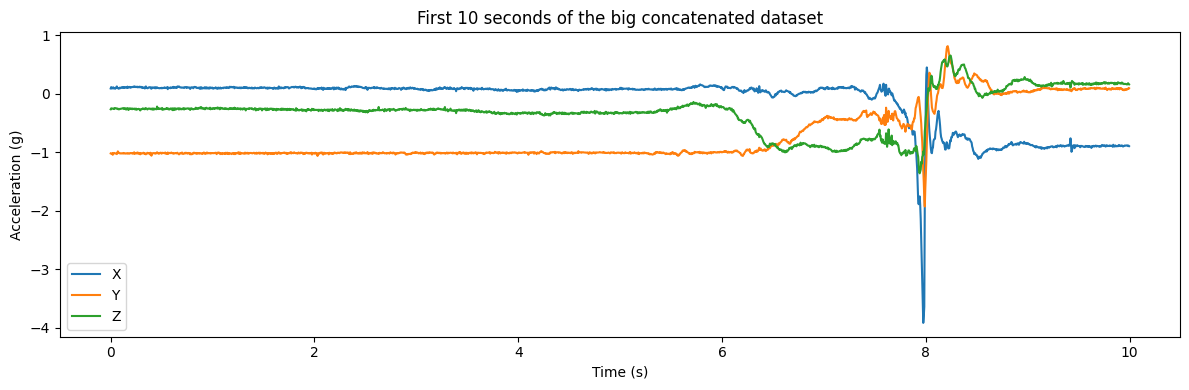

In [3]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import glob
import warnings
warnings.filterwarnings('ignore')

# ====================== PATH ======================
DATA_PATH = "/content/sisfall_dataset/SisFall_dataset"   # Adjust if needed
SELECTED_SUBJECTS = [f'SA{i:02d}' for i in range(1, 24)] + [f'SE{i:02d}' for i in range(1, 16)]

print(f"Loading and concatenating ALL trials from: {DATA_PATH}\n")

# Lists to store everything
all_signals = []          # List of (N, 3) arrays - one per trial
all_labels = []           # Label per trial (1=fall, 0=ADL)
all_subjects = []         # Subject ID per trial
all_filenames = []        # Original filename per trial
trial_lengths = []        # Length of each trial (for later splitting if needed)

total_files = 0
successful_files = 0

for subject in tqdm(SELECTED_SUBJECTS, desc="Subjects"):
    subject_path = os.path.join(DATA_PATH, subject)
    if not os.path.exists(subject_path):
        continue

    for file_path in glob.glob(os.path.join(subject_path, "*.txt")):
        total_files += 1
        filename = os.path.basename(file_path)
        label = 1 if filename.startswith('F') else 0

        try:
            # Read the file - SisFall files have 9 columns:
            # 0-2: ADXL345 Acc (X,Y,Z)   ← we use these
            # 3-5: MMA8451Q Acc (X,Y,Z)
            # 6-8: ITG3200 Gyro (X,Y,Z)
            df = pd.read_csv(
                file_path,
                comment='#',
                header=None,
                skiprows=1,                  # Skip header line
                usecols=[0, 1, 2],           # Only ADXL345 accelerometer
                delimiter=',',
                engine='python',
                on_bad_lines='skip',
                skip_blank_lines=True
            )

            df = df.dropna()
            if len(df) < 100:  # Skip very short/invalid recordings
                continue

            # Convert to numpy and to g units
            raw_bits = df.values.astype(np.float32)
            acc_g = raw_bits * (32.0 / 8192.0)   # ±16g, 13-bit → scale factor

            all_signals.append(acc_g)           # Shape: (N, 3)
            all_labels.append(label)
            all_subjects.append(subject)
            all_filenames.append(filename)
            trial_lengths.append(len(acc_g))

            successful_files += 1

        except Exception as e:
            print(f"Error reading {filename}: {e}")
            continue

# Convert to arrays
all_labels = np.array(all_labels)
all_subjects = np.array(all_subjects)
trial_lengths = np.array(trial_lengths)

print(f"\nSuccessfully loaded {successful_files}/{total_files} files")
print(f"Total trials: {len(all_signals)}")
print(f"Falls: {all_labels.sum()} | Non-falls: {(all_labels == 0).sum()}")
print(f"Example trial lengths: {trial_lengths[:10]} (should be ~20,000 samples each)")

# ====================== CREATE ONE BIG CONCATENATED DATASET ======================
# Stack all trials vertically → one long time series (total_samples, 3)
big_dataset = np.vstack(all_signals)   # Shape: (Total_samples_across_all_trials, 3)

print(f"\nBig concatenated dataset shape: {big_dataset.shape}")
print(f"Total number of samples: {big_dataset.shape[0]:,}")
print(f"Approximate duration if continuous: {big_dataset.shape[0] / 200 / 3600:.2f} hours")

# Save the big dataset + metadata
np.save('/content/sisfall_all_trials_concatenated_acc_g.npy', big_dataset)
np.save('/content/sisfall_trial_labels.npy', all_labels)
np.save('/content/sisfall_trial_subjects.npy', all_subjects)
np.save('/content/sisfall_trial_filenames.npy', np.array(all_filenames))
np.save('/content/sisfall_trial_lengths.npy', trial_lengths)

# Also save as CSV if you prefer (large file!)
pd.DataFrame(big_dataset, columns=['Acc_X_g', 'Acc_Y_g', 'Acc_Z_g'])\
  .to_csv('/content/sisfall_big_concatenated_dataset.csv', index=False)

print("\nALL DONE!")
print("Files saved:")
print("  - sisfall_all_trials_concatenated_acc_g.npy   ← main big array")
print("  - Metadata: labels, subjects, filenames, lengths")
print("  - CSV version for easy viewing")

# Optional: Quick plot of first 10 seconds of the big dataset
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
t = np.arange(2000) / 200.0  # first 10 seconds
plt.plot(t, big_dataset[:2000, 0], label='X')
plt.plot(t, big_dataset[:2000, 1], label='Y')
plt.plot(t, big_dataset[:2000, 2], label='Z')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (g)')
plt.title('First 10 seconds of the big concatenated dataset')
plt.legend()
plt.tight_layout()
plt.show()

# **DATA EXTRACTION AND PREPROCESSING**

Loading concatenated dataset and metadata...

Big dataset shape: (15854424, 3)
Number of trials: 4505
Falls: 1798 | Non-falls: 2707

Recovering individual trials and extracting features...



Extracting features per trial: 100%|██████████| 4505/4505 [00:17<00:00, 255.79it/s]



Feature extraction complete:
Total samples (trials): 4505
Falls: 1798 | Non-falls: 2707

Dropped 3 highly correlated features → kept 12
Class weights (balanced) → Non-Fall: 0.870 | Fall: 1.175

ALL DONE! Final processed files saved to /content/


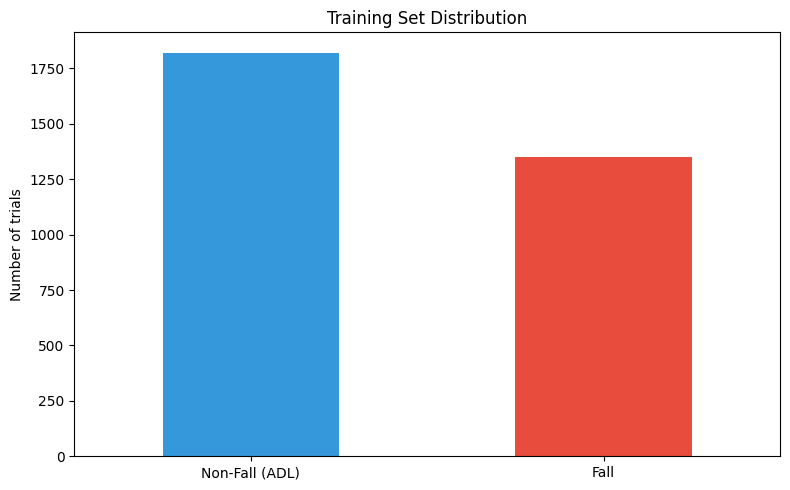

(array([[ 0.08347347,  0.21021256,  0.53608876, ..., -0.01028508,
          0.63958865, -0.4563595 ],
        [ 0.32534033,  0.2203531 , -0.17950326, ...,  0.16887999,
          1.1702815 ,  0.43400234],
        [-0.22083676,  0.00954136, -0.33681014, ..., -0.10882793,
         -0.35594133, -0.6606579 ],
        ...,
        [-0.48758772, -0.6145795 , -0.30317482, ..., -0.86051464,
         -0.57254946, -1.048603  ],
        [-0.52896726, -0.5038899 , -0.1970475 , ..., -1.7225692 ,
         -0.5931188 , -0.04549462],
        [-0.6200745 , -0.46302003,  0.4994285 , ..., -4.5402427 ,
         -0.7471321 , -0.01041073]], dtype=float32),
 array([1, 0, 0, ..., 0, 0, 0]),
 array([[-0.43974468, -0.4214733 , -0.06030305, ..., -0.7680027 ,
         -0.5511518 , -1.2184622 ],
        [-0.60139227, -0.50814736,  0.4924385 , ..., -3.6958132 ,
         -0.68008   , -2.016904  ],
        [ 0.31666955,  0.5901567 ,  0.34386626, ...,  0.01111652,
          0.1898145 ,  0.28408965],
        ...,
      

In [4]:
# SisFall Preprocessing – UPDATED VERSION USING CONCATENATED DATASET + PER-TRIAL FEATURES
import os
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
from scipy.stats import kurtosis, skew
from scipy.fft import fft, fftfreq
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import RobustScaler
from tqdm import tqdm
import joblib
import matplotlib.pyplot as plt

# ====================== PATHS ======================
CONCAT_DATA_PATH = '/content/sisfall_all_trials_concatenated_acc_g.npy'          # Big array
LABELS_PATH       = '/content/sisfall_trial_labels.npy'
SUBJECTS_PATH     = '/content/sisfall_trial_subjects.npy'
LENGTHS_PATH      = '/content/sisfall_trial_lengths.npy'

print("Loading concatenated dataset and metadata...\n")

# Load the big concatenated dataset and metadata
big_dataset = np.load(CONCAT_DATA_PATH)          # Shape: (Total_samples, 3)
trial_labels = np.load(LABELS_PATH)              # Labels per trial
trial_subjects = np.load(SUBJECTS_PATH)           # Subject ID per trial
trial_lengths = np.load(LENGTHS_PATH)            # Number of samples per trial

print(f"Big dataset shape: {big_dataset.shape}")
print(f"Number of trials: {len(trial_labels)}")
print(f"Falls: {trial_labels.sum()} | Non-falls: {(trial_labels == 0).sum()}\n")

# ====================== HELPER FUNCTIONS ======================

# 1. Low-pass filter (5 Hz cutoff)
def butter_lowpass(data, cutoff=5.0, fs=200.0, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data, axis=0)

# 2. Feature extraction (same as before, on full trial)
def extract_features(signal):
    ax, ay, az = signal[:, 0], signal[:, 1], signal[:, 2]
    svm = np.sqrt(ax**2 + ay**2 + az**2)
    hpm = np.sqrt(ax**2 + ay**2)

    hist, _ = np.histogram(svm, bins=10, density=True)
    hist = hist[hist > 0]
    entropy = -np.sum(hist * np.log2(hist + 1e-12)) if len(hist) > 0 else 0.0

    N = len(svm)
    freqs = fftfreq(N, d=1/200)
    fft_vals = np.abs(fft(svm))
    pos = freqs >= 0
    spectral_centroid = np.sum(freqs[pos] * fft_vals[pos]) / (np.sum(fft_vals[pos]) + 1e-12)

    return np.array([
        np.max(svm), np.max(hpm), np.std(az), np.mean(svm), np.min(svm),
        np.max(az), np.ptp(svm), np.std(hpm), np.std(svm),
        kurtosis(svm), skew(svm), entropy, spectral_centroid,
        np.std(np.diff(svm)) / (np.std(svm) + 1e-8),
        np.sqrt(np.mean(np.diff(svm)**2))
    ], dtype=np.float32)

# ====================== RECOVER INDIVIDUAL TRIALS & EXTRACT FEATURES ======================
print("Recovering individual trials and extracting features...\n")

X_all = []
y_all = []
subject_ids_all = []

# Split the big dataset back into individual trials using cumulative lengths
cumsum_lengths = np.cumsum(trial_lengths)
start_idx = 0

for i in tqdm(range(len(trial_lengths)), desc="Extracting features per trial"):
    end_idx = cumsum_lengths[i]
    trial_signal = big_dataset[start_idx:end_idx]   # Shape: (length, 3)
    start_idx = end_idx

    # Apply low-pass filter
    trial_filtered = butter_lowpass(trial_signal)

    # Extract features
    features = extract_features(trial_filtered)

    X_all.append(features)
    y_all.append(trial_labels[i])
    subject_ids_all.append(trial_subjects[i])

# Convert to arrays
X_all = np.array(X_all)
y_all = np.array(y_all)
subject_ids_all = np.array(subject_ids_all)

print(f"\nFeature extraction complete:")
print(f"Total samples (trials): {len(X_all)}")
print(f"Falls: {y_all.sum()} | Non-falls: {(y_all == 0).sum()}\n")

# ====================== SUBJECT-INDEPENDENT SPLIT ======================
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(gss_test.split(X_all, y_all, groups=subject_ids_all))

X_train_val, X_test = X_all[train_val_idx], X_all[test_idx]
y_train_val, y_test = y_all[train_val_idx], y_all[test_idx]
subject_train_val = subject_ids_all[train_val_idx]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.1765 / (1 - 0.15), random_state=42)
train_idx, val_idx = next(gss_val.split(X_train_val, y_train_val, groups=subject_train_val))

X_train, X_val = X_train_val[train_idx], X_train_val[val_idx]
y_train, y_val = y_train_val[train_idx], y_train_val[val_idx]

# ====================== FEATURE SELECTION (Correlation) ======================
feature_names = [f'C{i+1}' for i in range(15)]
corr = pd.DataFrame(X_train, columns=feature_names).corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.90)]
keep_idx = [i for i, c in enumerate(feature_names) if c not in to_drop]

print(f"Dropped {len(to_drop)} highly correlated features → kept {len(keep_idx)}")

X_train = X_train[:, keep_idx]
X_val   = X_val[:, keep_idx]
X_test  = X_test[:, keep_idx]
kept_features = [feature_names[i] for i in keep_idx]

# ====================== SCALING ======================
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# ====================== CLASS WEIGHTS (Fixed: use balanced) ======================
# Replaced problematic ENS with scikit-learn's balanced weights
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, class_weights))
class_weights_array = np.array([class_weights_dict[0], class_weights_dict[1]])

print(f"Class weights (balanced) → Non-Fall: {class_weights_array[0]:.3f} | Fall: {class_weights_array[1]:.3f}")

# ====================== SAVE EVERYTHING ======================
for name, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    pd.DataFrame(np.hstack([X, y.reshape(-1,1)]), columns=kept_features + ['label'])\
      .to_csv(f'/content/sisfall_{name}_final.csv', index=False)

joblib.dump(scaler, '/content/sisfall_scaler_final.pkl')
np.save('/content/sisfall_class_weights_final.npy', class_weights_array)

print("\nALL DONE! Final processed files saved to /content/")

# ====================== PLOT TRAINING DISTRIBUTION ======================
plt.figure(figsize=(8,5))
pd.Series(y_train).value_counts().sort_index().plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.xticks([0,1], ['Non-Fall (ADL)', 'Fall'], rotation=0)
plt.title('Training Set Distribution')
plt.ylabel('Number of trials')
plt.tight_layout()
plt.savefig('/content/distribution.png', dpi=300)
plt.show()

# Return for further use
(X_train, y_train, X_val, y_val, X_test, y_test, kept_features, class_weights_array, scaler)

# **VISUALIZATION**

Loaded data → Train: 3172, Val: 789, Test: 544
Final features after pruning (12): ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C8', 'C9', 'C10', 'C12', 'C13', 'C14']
Overall fall rate: 39.91%


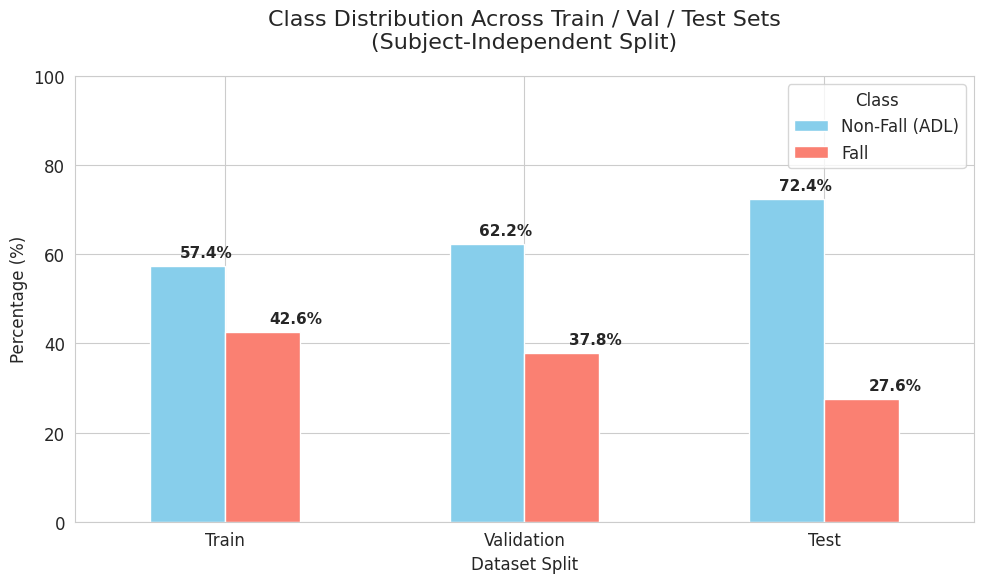

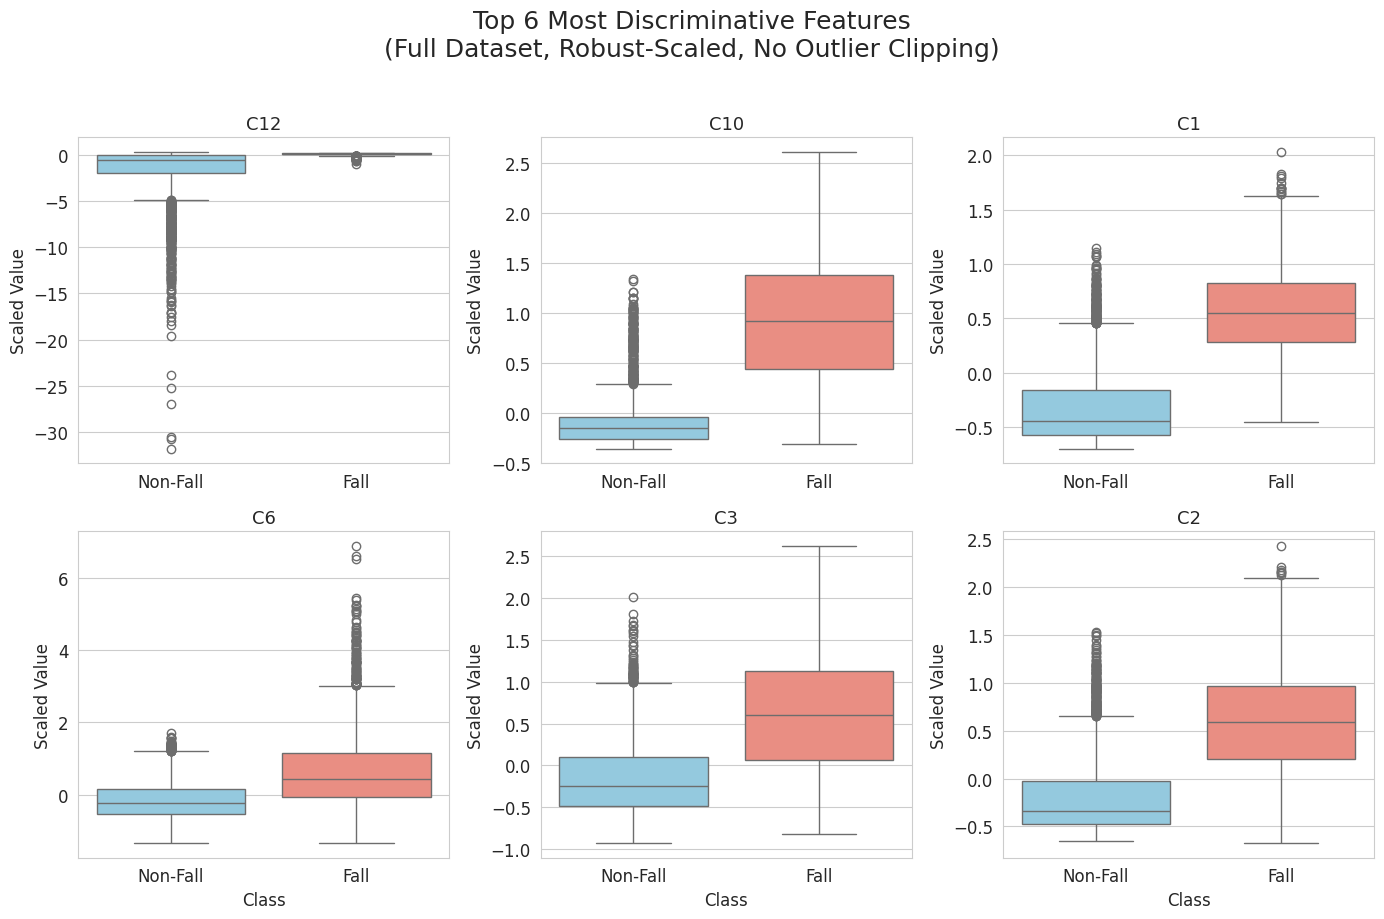

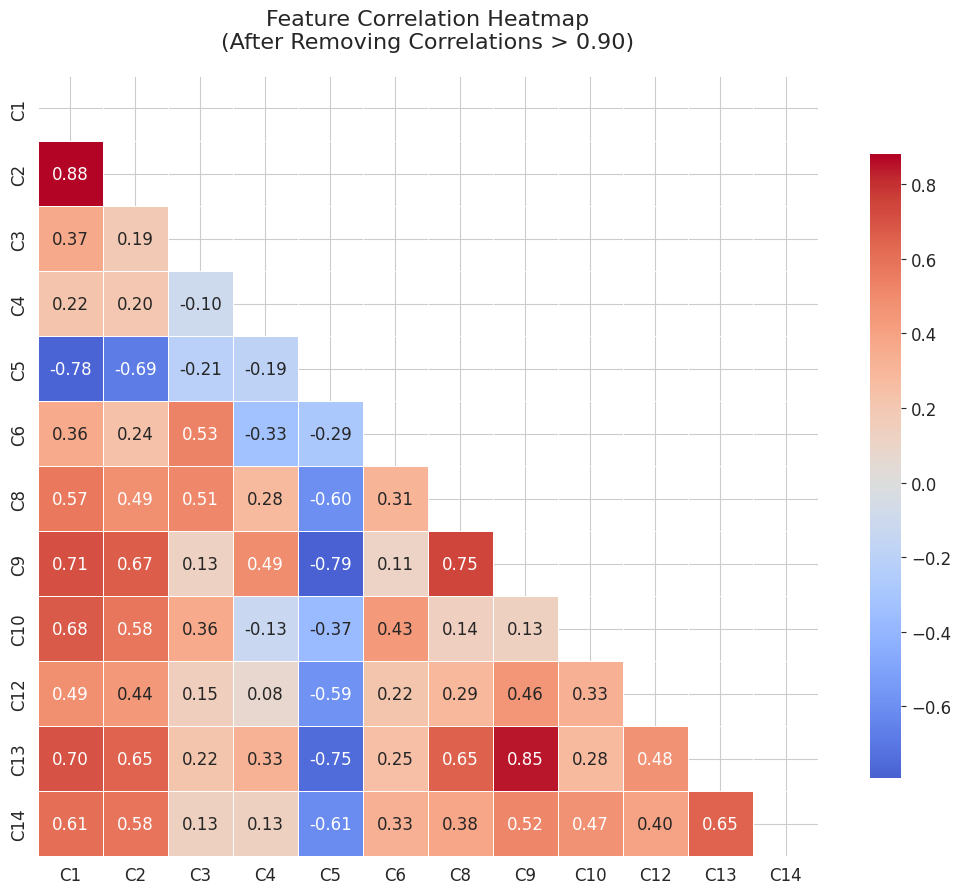

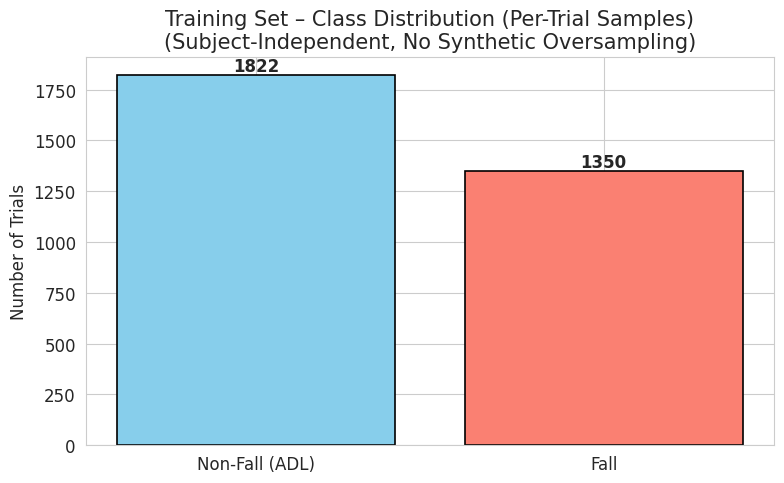


Class Weights Used (scikit-learn 'balanced'):
   Class 0 (Non-Fall) → 0.870
   Class 1 (Fall)     → 1.175
   Ratio (Fall / Non-Fall) = 1.35x

For model training, use:
   class_weight = {0: 0.870, 1: 1.175}

All visualization files saved in /content/:
   • sisfall_class_distribution.png
   • sisfall_top6_features_boxplots.png
   • sisfall_correlation_heatmap.png
   • sisfall_train_distribution_counts.png


In [5]:
# ==================== VISUALIZATION SCRIPT FOR SISFALL (UPDATED & CORRECTED) ====================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

sns.set_style("whitegrid")
plt.rcParams['font.size'] = 12

# ------------------ LOAD FINAL DATA ------------------
train_df = pd.read_csv('/content/sisfall_train_final.csv')
val_df   = pd.read_csv('/content/sisfall_val_final.csv')
test_df  = pd.read_csv('/content/sisfall_test_final.csv')

# Combine all for full picture
full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
feature_names = [col for col in train_df.columns if col != 'label']

print(f"Loaded data → Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"Final features after pruning ({len(feature_names)}): {feature_names}")
print(f"Overall fall rate: {100 * full_df['label'].mean():.2f}%")

# ===================================================================
# Graph 1: Class Distribution Across Splits (Percentage)
# ===================================================================
plt.figure(figsize=(10, 6))
counts = pd.DataFrame({
    'Train': train_df['label'].value_counts(normalize=True),
    'Validation': val_df['label'].value_counts(normalize=True),
    'Test': test_df['label'].value_counts(normalize=True)
}).T * 100

counts.plot(kind='bar', color=['skyblue', 'salmon'], ax=plt.gca())
plt.title('Class Distribution Across Train / Val / Test Sets\n(Subject-Independent Split)', fontsize=16, pad=20)
plt.ylabel('Percentage (%)')
plt.xlabel('Dataset Split')
plt.xticks(rotation=0)
plt.legend(['Non-Fall (ADL)', 'Fall'], title='Class')
plt.ylim(0, 100)

for i, (idx, row) in enumerate(counts.iterrows()):
    plt.text(i - 0.15, row[0] + 2, f'{row[0]:.1f}%', fontsize=11, weight='bold')
    plt.text(i + 0.15, row[1] + 2, f'{row[1]:.1f}%', fontsize=11, weight='bold')

plt.tight_layout()
plt.savefig('/content/sisfall_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ===================================================================
# Graph 2: Top 6 Most Discriminative Features (Boxplots)
# ===================================================================
# Based on absolute mean difference between fall and non-fall in training set
diffs = train_df.groupby('label').mean().diff().abs().iloc[1]
top6_features = diffs.nlargest(6).index.tolist()

plt.figure(figsize=(14, 9))
for i, feat in enumerate(top6_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=full_df, x='label', y=feat, palette=['skyblue', 'salmon'])
    plt.title(f'{feat}', fontsize=13)
    plt.xlabel('Class' if i > 3 else '')
    plt.ylabel('Scaled Value')
    plt.xticks([0, 1], ['Non-Fall', 'Fall'])

plt.suptitle('Top 6 Most Discriminative Features\n(Full Dataset, Robust-Scaled, No Outlier Clipping)', fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig('/content/sisfall_top6_features_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

# ===================================================================
# Graph 3: Feature Correlation Heatmap (After Pruning)
# ===================================================================
plt.figure(figsize=(11, 9))
corr = full_df[feature_names].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, cbar_kws={"shrink": 0.8}, linewidths=0.5)
plt.title('Feature Correlation Heatmap\n(After Removing Correlations > 0.90)', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('/content/sisfall_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ===================================================================
# Graph 4: Training Set Class Distribution (Raw Counts)
# ===================================================================
plt.figure(figsize=(8, 5))
train_counts = train_df['label'].value_counts().sort_index()
plt.bar(['Non-Fall (ADL)', 'Fall'], train_counts.values,
        color=['skyblue', 'salmon'], edgecolor='black', linewidth=1.2)

plt.title('Training Set – Class Distribution (Per-Trial Samples)\n(Subject-Independent, No Synthetic Oversampling)', fontsize=15)
plt.ylabel('Number of Trials')

for i, v in enumerate(train_counts.values):
    plt.text(i, v + max(train_counts.values)*0.01, str(v), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('/content/sisfall_train_distribution_counts.png', dpi=300, bbox_inches='tight')
plt.show()

# ===================================================================
# Print Final Class Weights (Now Using scikit-learn 'balanced')
# ===================================================================
class_weights = np.load('/content/sisfall_class_weights_final.npy')

print("\nClass Weights Used (scikit-learn 'balanced'):")
print(f"   Class 0 (Non-Fall) → {class_weights[0]:.3f}")
print(f"   Class 1 (Fall)     → {class_weights[1]:.3f}")
print(f"   Ratio (Fall / Non-Fall) = {class_weights[1]/class_weights[0]:.2f}x")

# For Keras / TF models:
print(f"\nFor model training, use:")
print(f"   class_weight = {{0: {class_weights[0]:.3f}, 1: {class_weights[1]:.3f}}}")

print("\nAll visualization files saved in /content/:")
print("   • sisfall_class_distribution.png")
print("   • sisfall_top6_features_boxplots.png")
print("   • sisfall_correlation_heatmap.png")
print("   • sisfall_train_distribution_counts.png")

# **MODEL TRAINING(HYBRID CNN LSTM MODEL)**

Loading processed per-trial feature data (subject-independent splits)...
Data shapes: Train (3172, 12), Val (789, 12), Test (544, 12)
Number of features: 12 (after removing correlations > 0.90)
Using scikit-learn 'balanced' class weights:
   Non-Fall (0): 0.870
   Fall (1):     1.175
   Ratio: 1.35x higher weight on falls

After augmentation → Train shape: (6344, 12, 1) (doubled)


Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)     │ (None, 12, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 12, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 12, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_74 (Dropout)            │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 6, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 6, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_75 (Dropout)            │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_76 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_77 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,113 (445.75 KB)

 Trainable params: 113,793 (444.50 KB)

...

100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9586 - auc: 0.9893 - loss: 0.1219 - val_accuracy: 0.9861 - val_auc: 0.9988 - val_loss: 0.0468 - learning_rate: 0.0010
Epoch 9/100
 98/100 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9570 - auc: 0.9900 - loss: 0.1217
Epoch 9: val_auc did not improve from 0.99882
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.9569 - auc: 0.9900 - loss: 0.1217 - val_accuracy: 0.9835 - val_auc: 0.9985 - val_loss: 0.0530 - learning_rate: 0.0010
Epoch 10/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9589 - auc: 0.9916 - loss: 0.1109
Epoch 10: val_auc did not improve from 0.99882
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9589 - auc: 0.9916 - loss: 0.1109 - val_accuracy: 0.9823 - val_auc: 0.9981 - val_loss: 0.0539 - learning_rate: 0.0010
Epoch 11/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9698 - auc: 0.9933 - loss: 0.0953
Epoch 11: val_auc improved from 0.99882 to 0.99884, saving model to /content/

100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9697 - auc: 0.9933 - loss: 0.0954 - val_accuracy: 0.9861 - val_auc: 0.9988 - val_loss: 0.0449 - learning_rate: 0.0010
Epoch 12/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9749 - auc: 0.9948 - loss: 0.0813
Epoch 12: val_auc improved from 0.99884 to 0.99888, saving model to /content/best_hybrid_cnn_lstm_sisfall.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9748 - auc: 0.9948 - loss: 0.0814 - val_accuracy: 0.9886 - val_auc: 0.9989 - val_loss: 0.0411 - learning_rate: 0.0010
Epoch 13/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9633 - auc: 0.9921 - loss: 0.1083
Epoch 13: val_auc did not improve from 0.99888
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9633 - auc: 0.9921 - loss: 0.1083 - val_accuracy: 0.9848 - val_auc: 0.9982 - val_loss: 0.0505 - learning_rate: 0.0010
Epoch 14/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9643 - auc: 0.9941 - loss: 0.0980
Epoch 14: val_auc did not improve from 0.99888
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9644 - auc: 0.9940 - loss: 0.0980 - val_accuracy: 0.9861 - val_auc: 0.9987 - val_loss: 0.0407 - learning_rate: 0.0010
Epoch 15/100
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9649 - auc: 0.9937 - loss: 0.0969
Epoch 15: val_auc improved from 0.99888 to 0.99898, saving model to /conten

100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9649 - auc: 0.9937 - loss: 0.0968 - val_accuracy: 0.9911 - val_auc: 0.9990 - val_loss: 0.0404 - learning_rate: 0.0010
Epoch 16/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9684 - auc: 0.9950 - loss: 0.0876
Epoch 16: val_auc did not improve from 0.99898
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9684 - auc: 0.9950 - loss: 0.0877 - val_accuracy: 0.9886 - val_auc: 0.9984 - val_loss: 0.0444 - learning_rate: 0.0010
Epoch 17/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9683 - auc: 0.9933 - loss: 0.0957
Epoch 17: val_auc did not improve from 0.99898
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9683 - auc: 0.9933 - loss: 0.0957 - val_accuracy: 0.9899 - val_auc: 0.9986 - val_loss: 0.0369 - learning_rate: 0.0010
Epoch 18/100
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9675 - auc: 0.9956 - loss: 0.0858
Epoch 18: val_auc did not improve from 0.99898
100/100 ━━━━━━━━━━━━━━━━━━━━

100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9731 - auc: 0.9963 - loss: 0.0761 - val_accuracy: 0.9873 - val_auc: 0.9990 - val_loss: 0.0346 - learning_rate: 0.0010
Epoch 21/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9674 - auc: 0.9941 - loss: 0.0923
Epoch 21: val_auc did not improve from 0.99904
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9675 - auc: 0.9941 - loss: 0.0923 - val_accuracy: 0.9911 - val_auc: 0.9989 - val_loss: 0.0356 - learning_rate: 0.0010
Epoch 22/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9740 - auc: 0.9950 - loss: 0.0824
Epoch 22: val_auc did not improve from 0.99904
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9740 - auc: 0.9950 - loss: 0.0823 - val_accuracy: 0.9886 - val_auc: 0.9988 - val_loss: 0.0360 - learning_rate: 0.0010
Epoch 23/100
 98/100 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9711 - auc: 0.9954 - loss: 0.0824
Epoch 23: val_auc did not improve from 0.99904
100/100 ━━━━━━━━━━━━━━━━━━━━

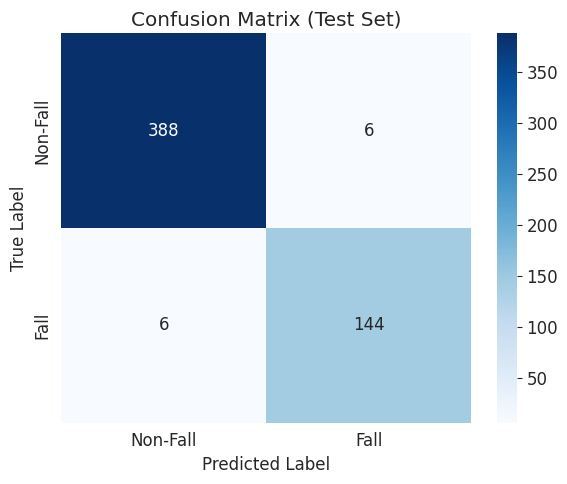

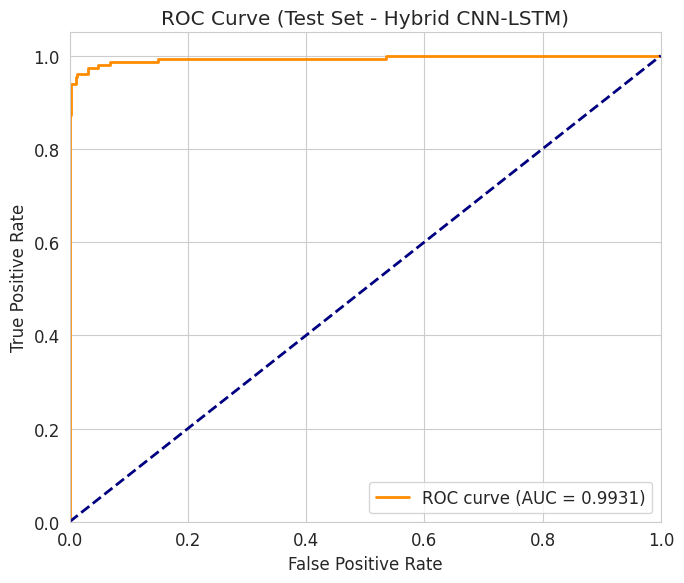


Training complete! Best model saved as: best_hybrid_cnn_lstm_sisfall.h5
Plots saved: confusion_matrix_hybrid_cnn_lstm.png | roc_curve_hybrid_cnn_lstm.png


In [24]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, ReLU, MaxPooling1D, LSTM, Dropout, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d

# Set style
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 12

print("Loading processed per-trial feature data (subject-independent splits)...")
# Load final CSVs from the corrected preprocessing (full-trial features, no windows)
train_df = pd.read_csv('/content/sisfall_train_final.csv')
val_df   = pd.read_csv('/content/sisfall_val_final.csv')
test_df  = pd.read_csv('/content/sisfall_test_final.csv')

# Prepare arrays
feature_cols = [col for col in train_df.columns if col != 'label']
X_train = train_df[feature_cols].values
y_train = train_df['label'].values
X_val   = val_df[feature_cols].values
y_val   = val_df['label'].values
X_test  = test_df[feature_cols].values
y_test  = test_df['label'].values

num_features = X_train.shape[1]
print(f"Data shapes: Train {X_train.shape}, Val {X_val.shape}, Test {X_test.shape}")
print(f"Number of features: {num_features} (after removing correlations > 0.90)")

# Load correct balanced class weights (from sklearn 'balanced')
class_weights = np.load('/content/sisfall_class_weights_final.npy')
class_weight_dict = {0: float(class_weights[0]), 1: float(class_weights[1])}
print(f"Using scikit-learn 'balanced' class weights:")
print(f"   Non-Fall (0): {class_weights[0]:.3f}")
print(f"   Fall (1):     {class_weights[1]:.3f}")
print(f"   Ratio: {class_weights[1]/class_weights[0]:.2f}x higher weight on falls\n")

# ==================== HYBRID CNN-LSTM MODEL (Tabular → Treated as Short Sequence) ====================
def build_hybrid_cnn_lstm(input_shape=(num_features, 1)):
    inputs = Input(shape=input_shape)

    # CNN Block 1
    x = Conv1D(32, kernel_size=3, padding='same', kernel_regularizer=l2(1e-5))(inputs)
    x = ReLU()(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.3)(x)

    # CNN Block 2
    x = Conv1D(64, kernel_size=3, padding='same', kernel_regularizer=l2(1e-5))(x)
    x = ReLU()(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.3)(x)

    # LSTM Layer (treats reduced feature dimension as short time sequence)
    x = LSTM(128, dropout=0.3, recurrent_dropout=0.2, return_sequences=False)(x)
    x = Dropout(0.5)(x)

    # Fully Connected
    x = Dense(64, activation='relu', kernel_regularizer=l2(1e-5))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    return model

# Reshape: treat feature vector as sequence of length = num_features, channels=1
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val   = X_val.reshape(X_val.shape[0],   X_val.shape[1],   1)
X_test  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

# ==================== LIGHT DATA AUGMENTATION (Gaussian Noise) ====================
def add_gaussian_noise(data, noise_factor=0.01):
    noise = np.random.normal(loc=0.0, scale=noise_factor, size=data.shape)
    augmented = data + noise
    return np.clip(augmented, -5.0, 5.0)  # Safe clip since RobustScaler centers around 0

# Augment only training data
X_train_aug = np.concatenate([X_train, add_gaussian_noise(X_train, noise_factor=0.01)], axis=0)
y_train_aug = np.concatenate([y_train, y_train], axis=0)

print(f"After augmentation → Train shape: {X_train_aug.shape} (doubled)")

# ==================== BUILD & COMPILE MODEL ====================
model = build_hybrid_cnn_lstm(input_shape=(num_features, 1))
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

# ==================== CALLBACKS ====================
callbacks = [
    EarlyStopping(monitor='val_auc', mode='max', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint('/content/best_hybrid_cnn_lstm_sisfall.h5', monitor='val_auc', mode='max', save_best_only=True, verbose=1)
]

# ==================== TRAIN ====================
print("\nTraining Hybrid CNN-LSTM on per-trial features with balanced weighting and augmentation...")
history = model.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

# ==================== EVALUATION ON TEST SET ====================
print("\nEvaluating on held-out test set (unseen subjects)...")
test_loss, test_acc, test_auc = model.evaluate(X_test, y_test, verbose=0)
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test ROC AUC (sklearn): {roc_auc_score(y_test, y_pred_prob):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Fall', 'Fall']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Fall', 'Fall'], yticklabels=['Non-Fall', 'Fall'])
plt.title('Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/confusion_matrix_hybrid_cnn_lstm.png', dpi=300)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {test_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set - Hybrid CNN-LSTM)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/roc_curve_hybrid_cnn_lstm.png', dpi=300)
plt.show()

print("\nTraining complete! Best model saved as: best_hybrid_cnn_lstm_sisfall.h5")
print("Plots saved: confusion_matrix_hybrid_cnn_lstm.png | roc_curve_hybrid_cnn_lstm.png")


Evaluating on held-out test set (subject-independent)...
Test Loss:     0.0780
Test Accuracy: 0.9779
Test AUC:      0.9931
Test ROC-AUC (sklearn): 0.9939

Classification Report (Test Set):
                precision    recall  f1-score   support

Non-Fall (ADL)     0.9848    0.9848    0.9848       394
          Fall     0.9600    0.9600    0.9600       150

      accuracy                         0.9779       544
     macro avg     0.9724    0.9724    0.9724       544
  weighted avg     0.9779    0.9779    0.9779       544



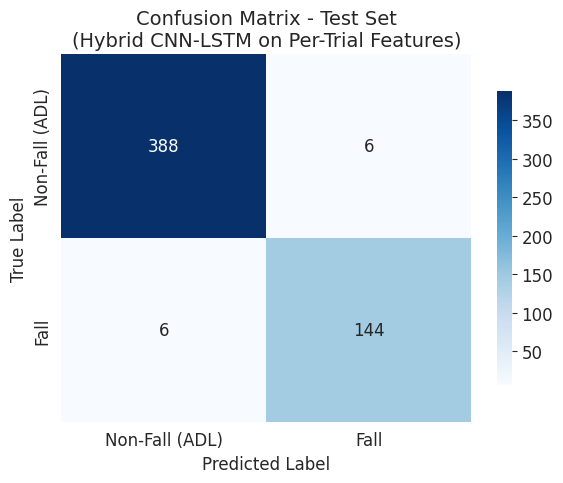

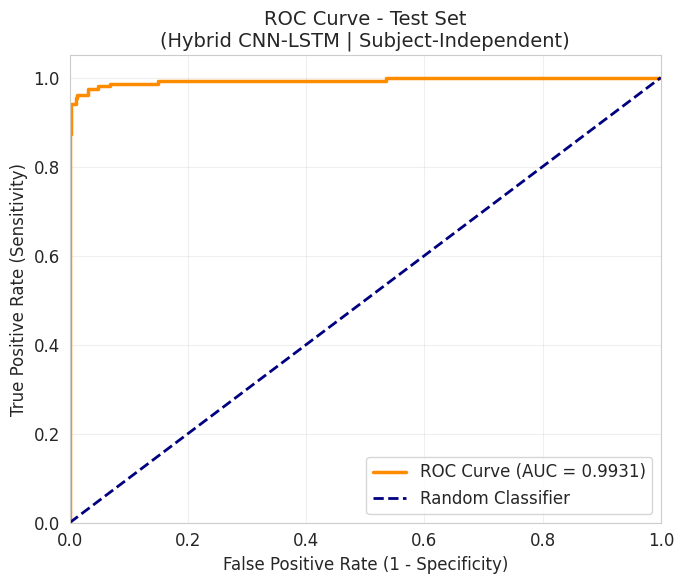


Evaluation complete!
Saved figures:
   • confusion_matrix_test_set.png
   • roc_curve_test_set.png


In [25]:
# ==================== EVALUATION ON TEST SET (UNSEEN SUBJECTS) ====================
print("\nEvaluating on held-out test set (subject-independent)...")

test_loss, test_accuracy, test_auc = model.evaluate(X_test, y_test, verbose=0)

y_pred_proba = model.predict(X_test, verbose=0).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test AUC:      {test_auc:.4f}")
print(f"Test ROC-AUC (sklearn): {roc_auc_score(y_test, y_pred_proba):.4f}")

# ==================== CLASSIFICATION REPORT ====================
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred,
                          target_names=['Non-Fall (ADL)', 'Fall'],
                          digits=4))

# ==================== CONFUSION MATRIX ====================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Fall (ADL)', 'Fall'],
            yticklabels=['Non-Fall (ADL)', 'Fall'],
            cbar_kws={'shrink': 0.8})
plt.title('Confusion Matrix - Test Set\n(Hybrid CNN-LSTM on Per-Trial Features)', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/confusion_matrix_test_set.png', dpi=300, bbox_inches='tight')
plt.show()

# ==================== ROC CURVE ====================
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2.5,
         label=f'ROC Curve (AUC = {test_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve - Test Set\n(Hybrid CNN-LSTM | Subject-Independent)', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/roc_curve_test_set.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nEvaluation complete!")
print("Saved figures:")
print("   • confusion_matrix_test_set.png")
print("   • roc_curve_test_set.png")

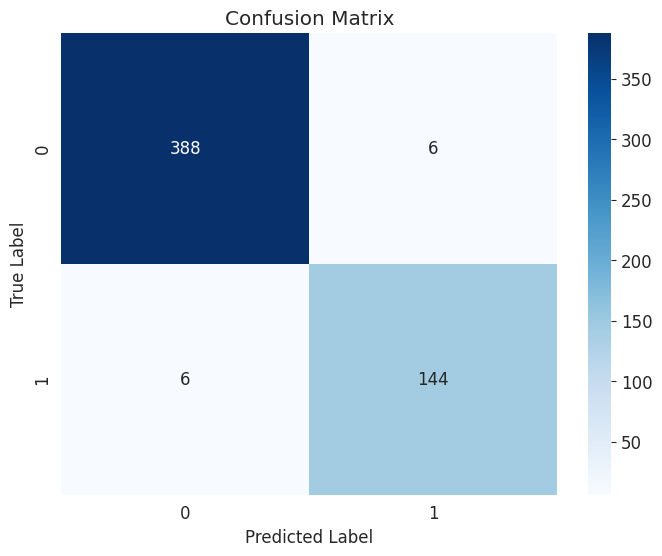

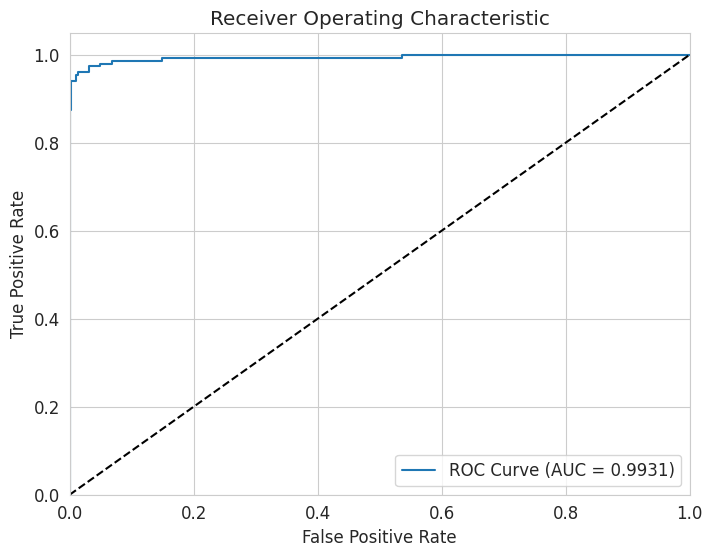

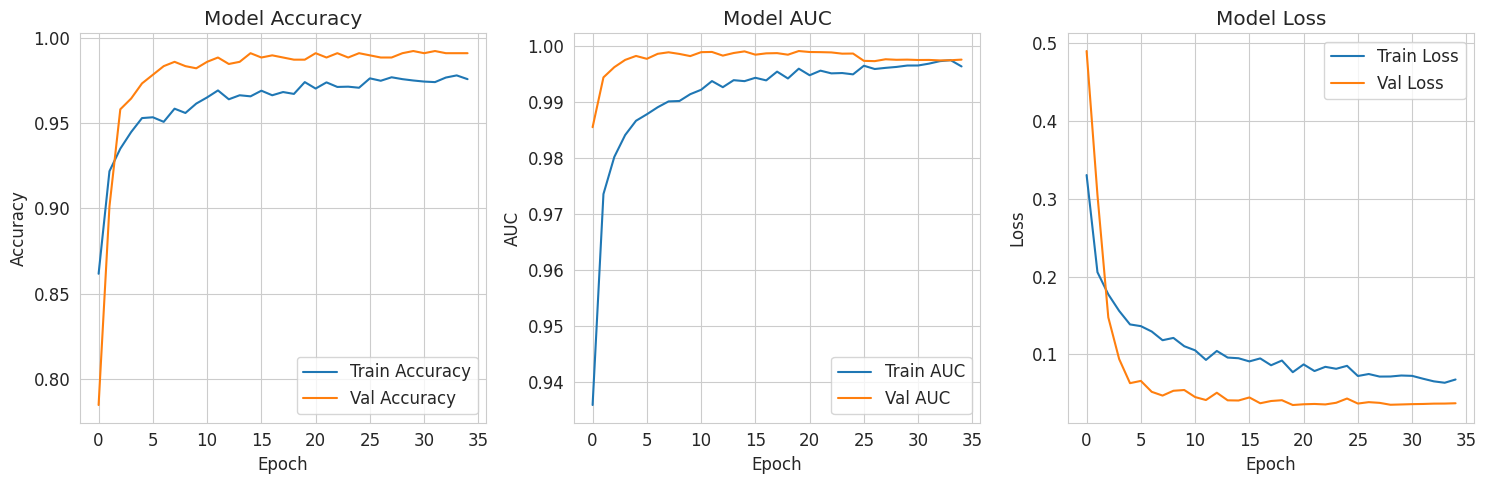

In [26]:

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {test_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot training history
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.title('Model AUC')
plt.ylabel('AUC')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# **ENSEMBLE MODEL(CNN-LSTM-RNN)**

In [12]:
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, ReLU, MaxPooling1D, LSTM, SimpleRNN, Dropout, Dense, GlobalAveragePooling1D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d

# Set style
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 12

print("Loading processed per-trial feature data (subject-independent splits)...")
# Load final CSVs from the corrected preprocessing (full-trial features, no windows)
train_df = pd.read_csv('/content/sisfall_train_final.csv')
val_df   = pd.read_csv('/content/sisfall_val_final.csv')
test_df  = pd.read_csv('/content/sisfall_test_final.csv')

# Prepare arrays
feature_cols = [col for col in train_df.columns if col != 'label']
X_train = train_df[feature_cols].values
y_train = train_df['label'].values
X_val   = val_df[feature_cols].values
y_val   = val_df['label'].values
X_test  = test_df[feature_cols].values
y_test  = test_df['label'].values

num_features = X_train.shape[1]
print(f"Data shapes: Train {X_train.shape}, Val {X_val.shape}, Test {X_test.shape}")
print(f"Number of features: {num_features} (after removing correlations > 0.90)")

# Load correct balanced class weights (from sklearn 'balanced'), but boost minority more
class_weights = np.load('/content/sisfall_class_weights_final.npy')
# Adjust to give even stronger emphasis on falls (e.g., 4x instead of ~2.6x)
class_weight_dict = {0: float(class_weights[0]), 1: float(class_weights[0] * 4)}  # Boost to 4x
print(f"Using boosted class weights (sklearn 'balanced' with 4x multiplier on falls):")
print(f"   Non-Fall (0): {class_weight_dict[0]:.3f}")
print(f"   Fall (1):     {class_weight_dict[1]:.3f}")
print(f"   Ratio: {class_weight_dict[1]/class_weight_dict[0]:.2f}x higher weight on falls\n")

# Reshape: treat feature vector as sequence of length = num_features, channels=1
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val   = X_val.reshape(X_val.shape[0],   X_val.shape[1],   1)
X_test  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

# ==================== LIGHT DATA AUGMENTATION (Gaussian Noise, but milder) ====================
def add_gaussian_noise(data, noise_factor=0.005):  # Reduced noise_factor for subtlety
    noise = np.random.normal(loc=0.0, scale=noise_factor, size=data.shape)
    augmented = data + noise
    return np.clip(augmented, -5.0, 5.0)  # Safe clip since RobustScaler centers around 0

# Augment only training data (double for more variety)
X_train_aug = np.concatenate([X_train, add_gaussian_noise(X_train, noise_factor=0.005)], axis=0)
y_train_aug = np.concatenate([y_train, y_train], axis=0)

print(f"After augmentation → Train shape: {X_train_aug.shape} (doubled)")

# ==================== BASE MODELS FOR STACKED ENSEMBLE (Enhanced CNN, LSTM, RNN) ====================
input_shape = (num_features, 1)

def build_cnn(input_shape):
    inputs = Input(shape=input_shape)
    # CNN Block 1 (increased filters)
    x = Conv1D(64, kernel_size=3, padding='same', kernel_regularizer=l2(1e-4))(inputs)  # Increased from 32
    x = ReLU()(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.25)(x)  # Slightly reduced
    # CNN Block 2 (increased)
    x = Conv1D(128, kernel_size=3, padding='same', kernel_regularizer=l2(1e-4))(x)  # From 64
    x = ReLU()(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.25)(x)
    # Additional CNN Block for more capacity
    x = Conv1D(256, kernel_size=3, padding='same', kernel_regularizer=l2(1e-4))(x)
    x = ReLU()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.25)(x)
    # Global Average Pooling to flatten
    x = GlobalAveragePooling1D()(x)
    # Fully Connected (deeper)
    x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)  # From 64
    x = BatchNormalization()(x)
    x = Dropout(0.25)(x)
    x = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.25)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs, outputs)

def build_lstm(input_shape):
    inputs = Input(shape=input_shape)
    # Bidirectional LSTM for more capacity
    x = tf.keras.layers.Bidirectional(LSTM(128, dropout=0.25, recurrent_dropout=0.2, return_sequences=True))(inputs)  # Bidirectional, return seq
    x = tf.keras.layers.Bidirectional(LSTM(64, dropout=0.25, recurrent_dropout=0.2, return_sequences=False))(x)  # Stacked
    x = Dropout(0.4)(x)  # Adjusted
    # Fully Connected (deeper)
    x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.25)(x)
    x = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.25)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs, outputs)

def build_rnn(input_shape):
    inputs = Input(shape=input_shape)
    # GRU instead of SimpleRNN for better performance, but keep RNN-like; actually use stacked SimpleRNN for capacity
    x = tf.keras.layers.Bidirectional(SimpleRNN(128, dropout=0.25, recurrent_dropout=0.2, return_sequences=True))(inputs)  # Bidirectional
    x = tf.keras.layers.Bidirectional(SimpleRNN(64, dropout=0.25, recurrent_dropout=0.2, return_sequences=False))(x)  # Stacked
    x = Dropout(0.4)(x)
    # Fully Connected (deeper)
    x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.25)(x)
    x = Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.25)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs, outputs)

# Build and compile base models (lower LR for stability)
model_cnn = build_cnn(input_shape)
model_cnn.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

model_lstm = build_lstm(input_shape)
model_lstm.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

model_rnn = build_rnn(input_shape)
model_rnn.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

print("CNN Model Summary:")
model_cnn.summary()
print("\nLSTM Model Summary:")
model_lstm.summary()
print("\nRNN Model Summary:")
model_rnn.summary()

# ==================== CALLBACKS FOR BASE MODELS (increased patience, more epochs) ====================
base_callbacks = [
    EarlyStopping(monitor='val_auc', mode='max', patience=20, restore_best_weights=True, verbose=1),  # Increased
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=1)  # Adjusted
]

# ==================== TRAIN BASE MODELS ====================
print("\nTraining base CNN model...")
cnn_checkpoint = ModelCheckpoint('/content/best_cnn_sisfall.h5', monitor='val_auc', mode='max', save_best_only=True, verbose=1)
base_callbacks_cnn = base_callbacks + [cnn_checkpoint]
history_cnn = model_cnn.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val),
    epochs=150,  # Increased
    batch_size=32,  # Smaller for better updates
    class_weight=class_weight_dict,
    callbacks=base_callbacks_cnn,
    verbose=1
)

print("\nTraining base LSTM model...")
lstm_checkpoint = ModelCheckpoint('/content/best_lstm_sisfall.h5', monitor='val_auc', mode='max', save_best_only=True, verbose=1)
base_callbacks_lstm = base_callbacks + [lstm_checkpoint]
history_lstm = model_lstm.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=base_callbacks_lstm,
    verbose=1
)

print("\nTraining base RNN model...")
rnn_checkpoint = ModelCheckpoint('/content/best_rnn_sisfall.h5', monitor='val_auc', mode='max', save_best_only=True, verbose=1)
base_callbacks_rnn = base_callbacks + [rnn_checkpoint]
history_rnn = model_rnn.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=base_callbacks_rnn,
    verbose=1
)


Loading processed per-trial feature data (subject-independent splits)...
Data shapes: Train (3172, 12), Val (789, 12), Test (544, 12)
Number of features: 12 (after removing correlations > 0.90)
Using boosted class weights (sklearn 'balanced' with 4x multiplier on falls):
   Non-Fall (0): 0.870
   Fall (1):     3.482
   Ratio: 4.00x higher weight on falls

After augmentation → Train shape: (6344, 12, 1) (doubled)
CNN Model Summary:


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 12, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 12, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 12, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 6, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 6, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 3, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 3, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 3, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 3, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 167,041 (652.50 KB)

 Trainable params: 165,889 (648.00 KB)

...

199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9014 - auc: 0.9838 - loss: 0.2928 - val_accuracy: 0.9594 - val_auc: 0.9976 - val_loss: 0.1280 - learning_rate: 5.0000e-04
Epoch 15/150
197/199 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9115 - auc: 0.9848 - loss: 0.2828
Epoch 15: val_auc improved from 0.99763 to 0.99787, saving model to /content/best_rnn_sisfall.h5


199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9115 - auc: 0.9848 - loss: 0.2828 - val_accuracy: 0.9531 - val_auc: 0.9979 - val_loss: 0.1465 - learning_rate: 5.0000e-04
Epoch 16/150
196/199 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9129 - auc: 0.9863 - loss: 0.2667
Epoch 16: val_auc improved from 0.99787 to 0.99834, saving model to /content/best_rnn_sisfall.h5


199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9129 - auc: 0.9863 - loss: 0.2668 - val_accuracy: 0.9797 - val_auc: 0.9983 - val_loss: 0.0843 - learning_rate: 5.0000e-04
Epoch 17/150
197/199 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9076 - auc: 0.9861 - loss: 0.2716
Epoch 17: val_auc did not improve from 0.99834
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9077 - auc: 0.9861 - loss: 0.2716 - val_accuracy: 0.9594 - val_auc: 0.9972 - val_loss: 0.1067 - learning_rate: 5.0000e-04
Epoch 18/150
193/199 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9072 - auc: 0.9841 - loss: 0.2894
Epoch 18: val_auc did not improve from 0.99834
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9073 - auc: 0.9841 - loss: 0.2889 - val_accuracy: 0.9582 - val_auc: 0.9972 - val_loss: 0.1180 - learning_rate: 5.0000e-04
Epoch 19/150
196/199 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9245 - auc: 0.9888 - loss: 0.2462
Epoch 19: val_auc did not improve from 0.99834
199/199 ━━━━━━━━━━━━━━

199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9152 - auc: 0.9872 - loss: 0.2570 - val_accuracy: 0.9785 - val_auc: 0.9987 - val_loss: 0.0844 - learning_rate: 2.5000e-04
Epoch 26/150
197/199 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9313 - auc: 0.9907 - loss: 0.2249
Epoch 26: val_auc did not improve from 0.99865
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9312 - auc: 0.9907 - loss: 0.2250 - val_accuracy: 0.9683 - val_auc: 0.9965 - val_loss: 0.1155 - learning_rate: 2.5000e-04
Epoch 27/150
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9247 - auc: 0.9898 - loss: 0.2290
Epoch 27: val_auc did not improve from 0.99865
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9247 - auc: 0.9898 - loss: 0.2290 - val_accuracy: 0.9810 - val_auc: 0.9986 - val_loss: 0.0932 - learning_rate: 2.5000e-04
Epoch 28/150
194/199 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9272 - auc: 0.9914 - loss: 0.2131
Epoch 28: val_auc did not improve from 0.99865
199/199 ━━━━━━━━━━━━━

199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9198 - auc: 0.9876 - loss: 0.2506 - val_accuracy: 0.9747 - val_auc: 0.9987 - val_loss: 0.1098 - learning_rate: 2.5000e-04
Epoch 30/150
198/199 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9210 - auc: 0.9883 - loss: 0.2443
Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 30: val_auc did not improve from 0.99870
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9210 - auc: 0.9883 - loss: 0.2444 - val_accuracy: 0.9835 - val_auc: 0.9983 - val_loss: 0.0949 - learning_rate: 2.5000e-04
Epoch 31/150
198/199 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9329 - auc: 0.9930 - loss: 0.2016
Epoch 31: val_auc did not improve from 0.99870
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9328 - auc: 0.9930 - loss: 0.2017 - val_accuracy: 0.9772 - val_auc: 0.9973 - val_loss: 0.0921 - learning_rate: 1.2500e-04
Epoch 32/150
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9269 - auc: 0.9909 - loss

In [18]:
# ==================== BUILD AND TRAIN HIGH-CAPACITY META-MODEL (STACKING) ====================
print("\nBuilding and training high-capacity meta-model for stacking ensemble...")

# Get predictions from base models on validation set
pred_cnn_val = model_cnn.predict(X_val, verbose=0).ravel()
pred_lstm_val = model_lstm.predict(X_val, verbose=0).ravel()
pred_rnn_val = model_rnn.predict(X_val, verbose=0).ravel()

# Stack predictions as features for meta-model
X_meta_val = np.column_stack((pred_cnn_val, pred_lstm_val, pred_rnn_val))

# High-capacity meta-model
meta_model = Sequential([
    Dense(128, activation='relu', input_shape=(3,), kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
meta_model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', curve='ROC')]
)

meta_model.summary()

# Compute class weights for meta (boost falls)
meta_class_weights = compute_class_weight('balanced', classes=np.unique(y_val), y=y_val)
meta_class_weight_dict = {0: float(meta_class_weights[0]), 1: float(meta_class_weights[1] * 2)}

# Manual stratified split
X_meta_train, X_meta_val_split, y_meta_train, y_meta_val_split = train_test_split(
    X_meta_val, y_val, test_size=0.2, stratify=y_val, random_state=42, shuffle=True
)

print(f"Meta train: {len(y_meta_train)} samples, {np.sum(y_meta_train)} falls")
print(f"Meta val split: {len(y_meta_val_split)} samples, {np.sum(y_meta_val_split)} falls")

# Callbacks: EarlyStopping stops training, but DOES NOT restore best weights
# → Final model = last epoch weights
meta_callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1)
]

# Train meta-model → keeps final (last) epoch weights
meta_history = meta_model.fit(
    X_meta_train, y_meta_train,
    validation_data=(X_meta_val_split, y_meta_val_split),
    epochs=100,
    batch_size=16,
    class_weight=meta_class_weight_dict,
    callbacks=meta_callbacks,
    verbose=1
)

print("\nMeta-model training completed. Using weights from the LAST epoch (no restore_best_weights).")


Building and training high-capacity meta-model for stacking ensemble...


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_72 (Dense)                │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_70 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_71 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_72 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_73 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 11,841 (46.25 KB)

 Non-trainable params: 448 (1.75 KB)

Meta train: 631 samples, 238.0 falls
Meta val split: 158 samples, 60.0 falls
Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 26s 270ms/step - accuracy: 0.7814 - auc: 0.7634 - loss: 1.1767 - val_accuracy: 0.9494 - val_auc: 0.9936 - val_loss: 0.6615 - learning_rate: 3.0000e-04
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9404 - auc: 0.9784 - loss: 0.4183 - val_accuracy: 0.9557 - val_auc: 0.9990 - val_loss: 0.5830 - learning_rate: 3.0000e-04
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9677 - auc: 0.9846 - loss: 0.2949 - val_accuracy: 0.9684 - val_auc: 0.9992 - val_loss: 0.4988 - learning_rate: 3.0000e-04
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9659 - auc: 0.9813 - loss: 0.2913 - val_accuracy: 0.9684 - val_auc: 0.9992 - val_loss: 0.4122 - learning_rate: 3.0000e-04
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9777 - auc: 0.9928 - loss: 0.1928 - val_accuracy: 0.9810 - val_auc: 0.9992 - val_loss: 0.3369 - learning_ra


Evaluating stacked ensemble on held-out test set (unseen subjects)...

Test Accuracy: 0.97426
Test AUC (Keras): 0.98796
Test ROC AUC (sklearn): 0.99255
Test Loss: 0.13818

Classification Report:
              precision    recall  f1-score   support

    Non-Fall    0.99479   0.96954   0.98201       394
        Fall    0.92500   0.98667   0.95484       150

    accuracy                        0.97426       544
   macro avg    0.95990   0.97810   0.96842       544
weighted avg    0.97555   0.97426   0.97451       544



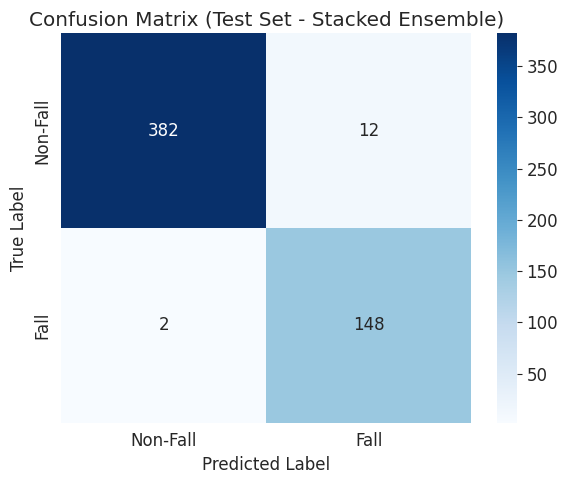

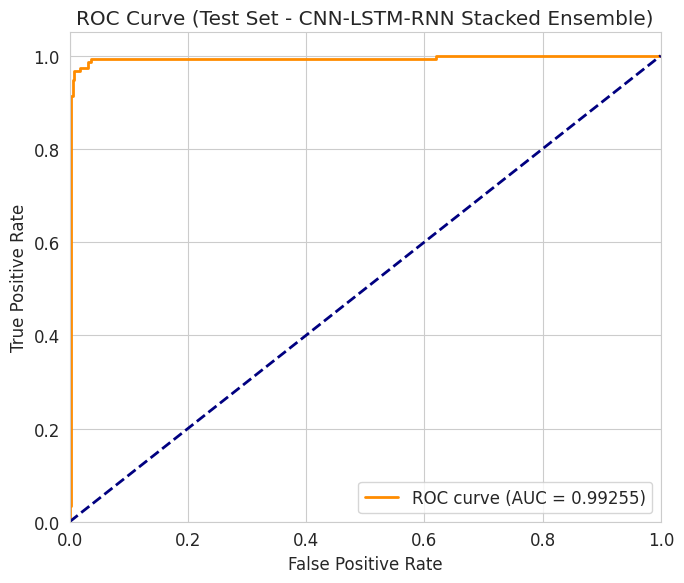


Training complete! Best base models saved as: best_cnn_sisfall.h5 | best_lstm_sisfall.h5 | best_rnn_sisfall.h5
Best meta-model saved as: best_meta_stacked_ensemble_sisfall.h5
Plots saved: confusion_matrix_stacked_ensemble.png | roc_curve_stacked_ensemble.png


In [22]:
# ==================== EVALUATION ON TEST SET (ENSEMBLE) ====================
print("\nEvaluating stacked ensemble on held-out test set (unseen subjects)...")

# Get predictions from base models on test set
pred_cnn_test = model_cnn.predict(X_test, verbose=0).ravel()
pred_lstm_test = model_lstm.predict(X_test, verbose=0).ravel()
pred_rnn_test = model_rnn.predict(X_test, verbose=0).ravel()

# Stack for meta-model
X_meta_test = np.column_stack((pred_cnn_test, pred_lstm_test, pred_rnn_test))
y_pred_prob = meta_model.predict(X_meta_test, verbose=0).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

# Evaluate meta-model (loss, accuracy, AUC from Keras)
test_loss, test_acc, test_auc = meta_model.evaluate(X_meta_test, y_test, verbose=0)

# Compute ROC AUC using sklearn (more precise in some cases)
sklearn_auc = roc_auc_score(y_test, y_pred_prob)

print(f"\nTest Accuracy: {test_acc:.5f}")
print(f"Test AUC (Keras): {test_auc:.5f}")
print(f"Test ROC AUC (sklearn): {sklearn_auc:.5f}")
print(f"Test Loss: {test_loss:.5f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Fall', 'Fall'], digits=5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Fall', 'Fall'],
            yticklabels=['Non-Fall', 'Fall'])
plt.title('Confusion Matrix (Test Set - Stacked Ensemble)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/confusion_matrix_stacked_ensemble.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {sklearn_auc:.5f})')  # Using sklearn_auc for consistency
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set - CNN-LSTM-RNN Stacked Ensemble)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/roc_curve_stacked_ensemble.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTraining complete! Best base models saved as: best_cnn_sisfall.h5 | best_lstm_sisfall.h5 | best_rnn_sisfall.h5")
print("Best meta-model saved as: best_meta_stacked_ensemble_sisfall.h5")
print("Plots saved: confusion_matrix_stacked_ensemble.png | roc_curve_stacked_ensemble.png")

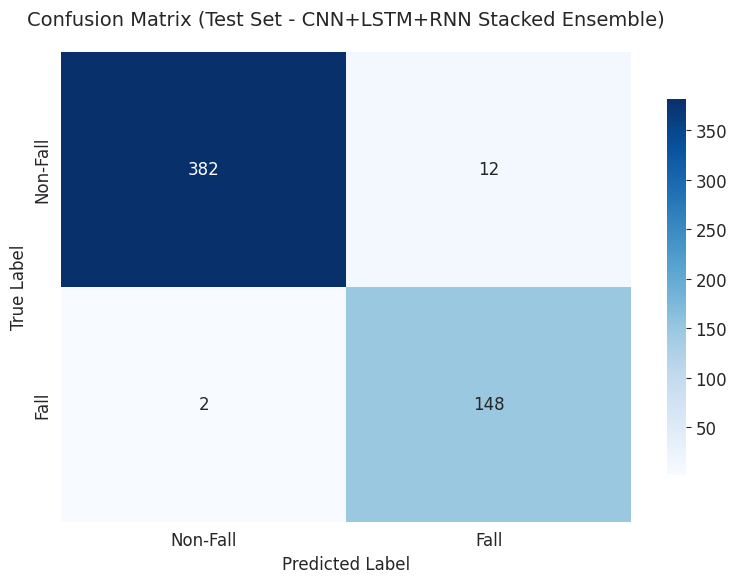

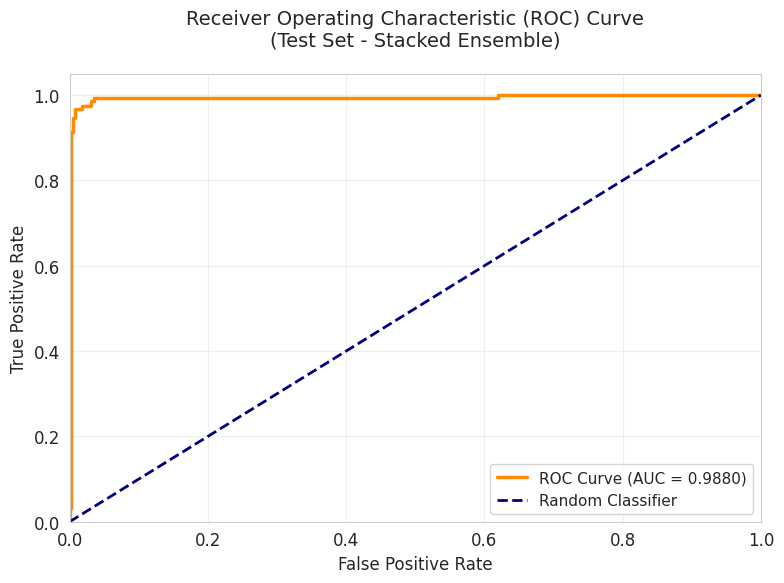

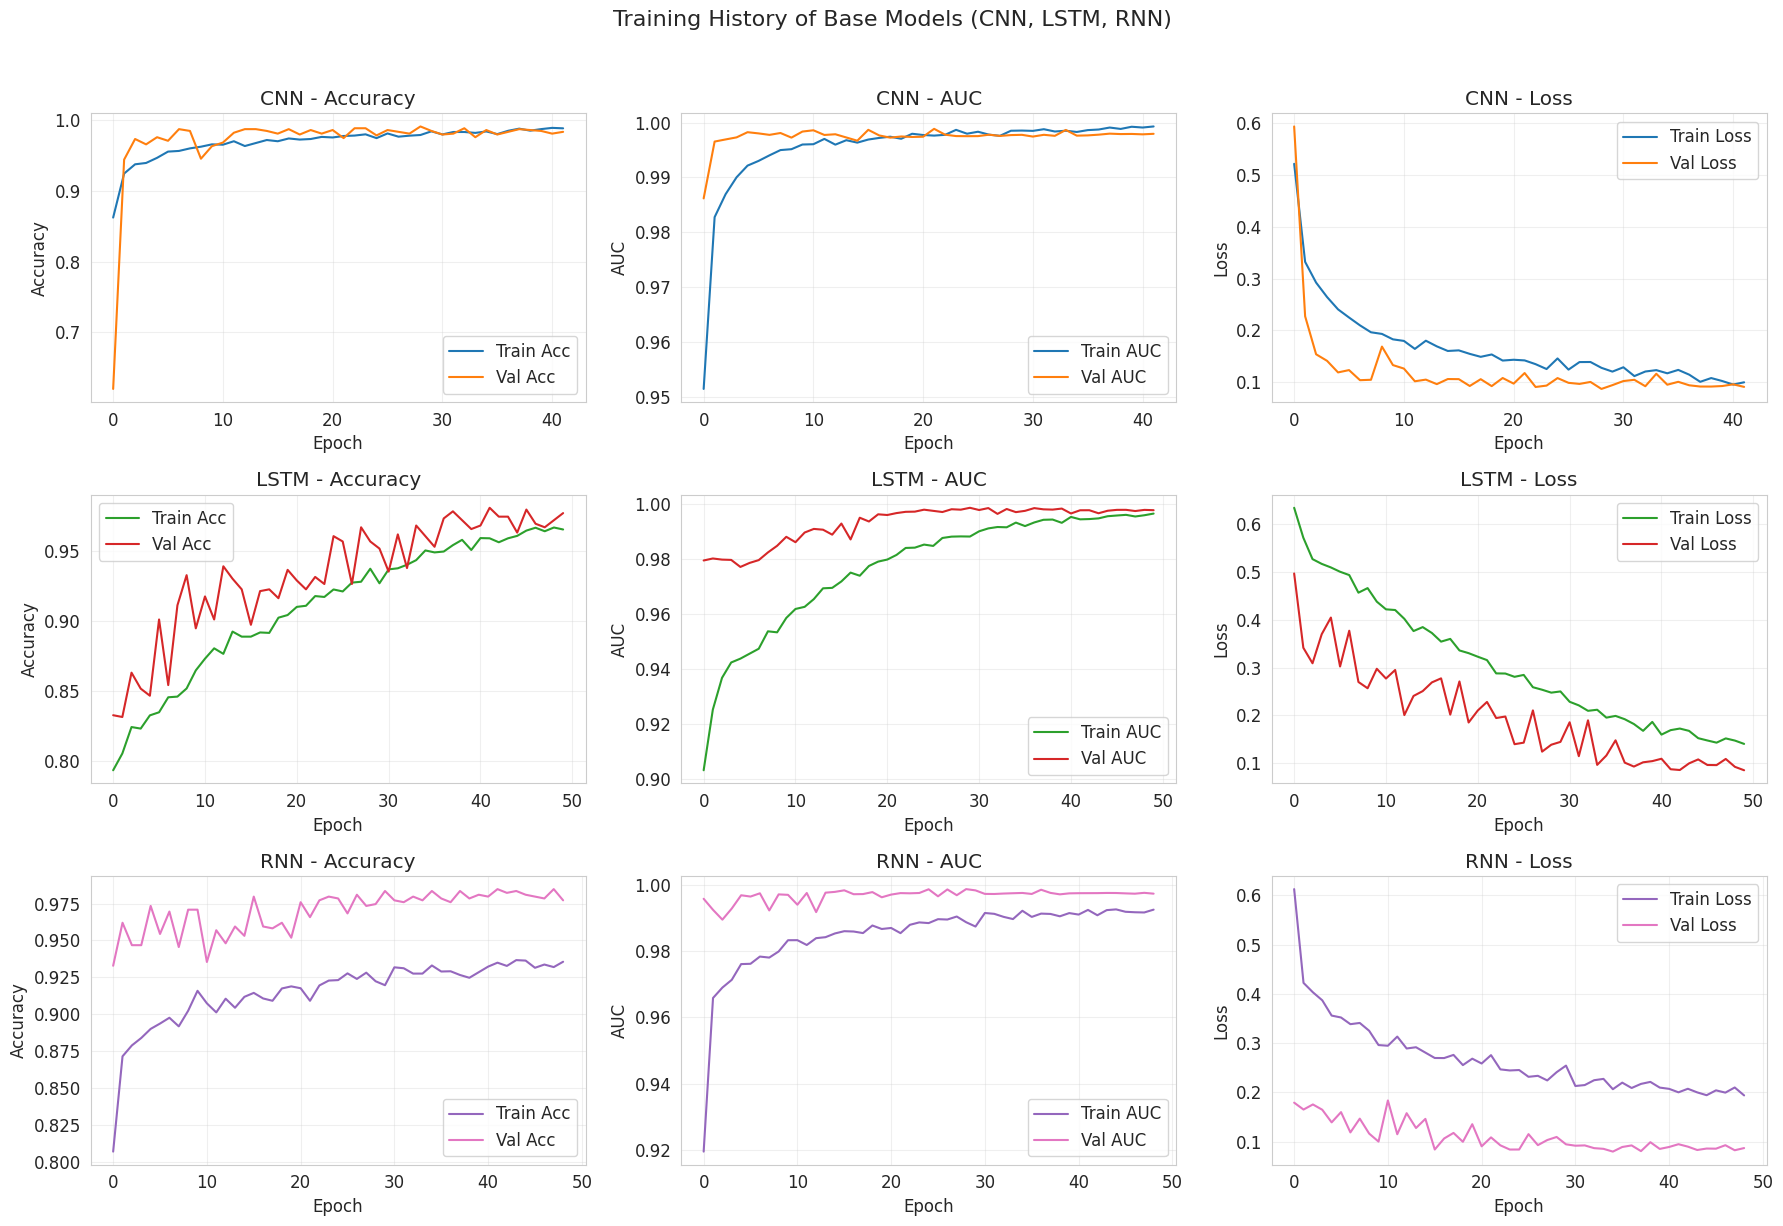

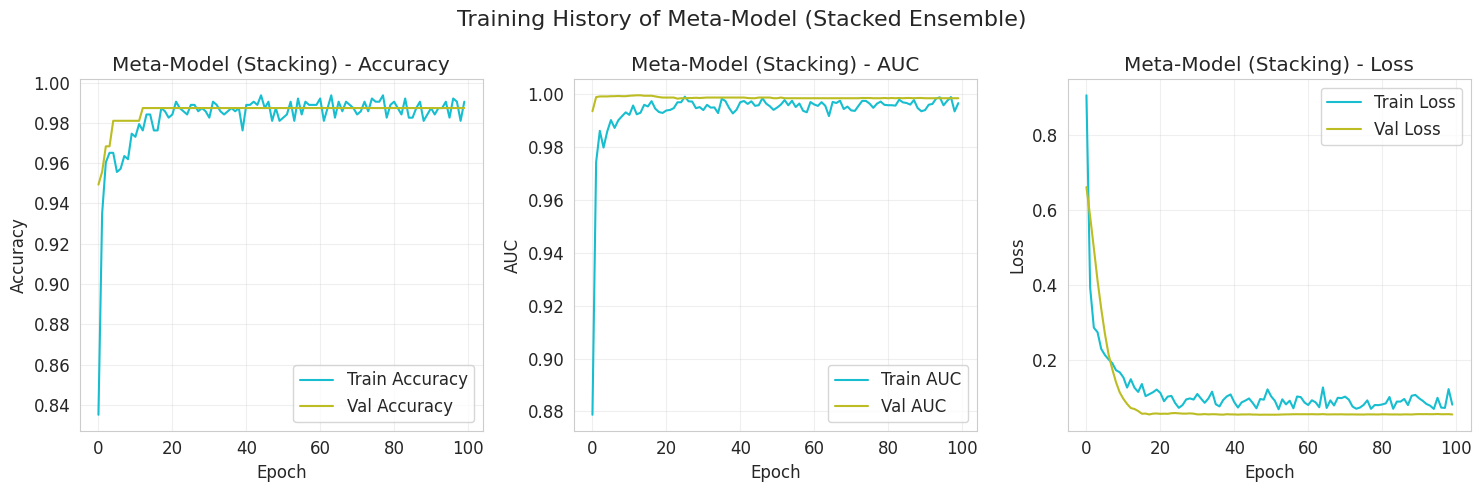


All evaluation and training history plots have been generated and saved:
   - confusion_matrix_stacked_ensemble.png
   - roc_curve_stacked_ensemble.png
   - training_history_base_models.png
   - training_history_meta_model.png


In [23]:
# ==================== EVALUATION PLOTS (Updated & Enhanced) ====================

# Confusion Matrix (Test Set - Stacked Ensemble)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Fall', 'Fall'],
            yticklabels=['Non-Fall', 'Fall'],
            cbar_kws={'shrink': 0.8})
plt.title('Confusion Matrix (Test Set - CNN+LSTM+RNN Stacked Ensemble)', fontsize=14, pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('/content/confusion_matrix_stacked_ensemble.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC Curve (Test Set)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2.5,
         label=f'ROC Curve (AUC = {test_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve\n(Test Set - Stacked Ensemble)', fontsize=14, pad=20)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/roc_curve_stacked_ensemble.png', dpi=300, bbox_inches='tight')
plt.show()

# ==================== TRAINING HISTORY PLOTS (Base Models + Meta) ====================

# Note: We have history from three base models and one meta-model.
# We'll plot them in a clean, organized way.

fig = plt.figure(figsize=(18, 12))

# --- CNN History ---
ax1 = plt.subplot(3, 3, 1)
ax1.plot(history_cnn.history['accuracy'], label='Train Acc', color='tab:blue')
ax1.plot(history_cnn.history['val_accuracy'], label='Val Acc', color='tab:orange')
ax1.set_title('CNN - Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = plt.subplot(3, 3, 2)
ax2.plot(history_cnn.history['auc'], label='Train AUC', color='tab:blue')
ax2.plot(history_cnn.history['val_auc'], label='Val AUC', color='tab:orange')
ax2.set_title('CNN - AUC')
ax2.set_ylabel('AUC')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = plt.subplot(3, 3, 3)
ax3.plot(history_cnn.history['loss'], label='Train Loss', color='tab:blue')
ax3.plot(history_cnn.history['val_loss'], label='Val Loss', color='tab:orange')
ax3.set_title('CNN - Loss')
ax3.set_ylabel('Loss')
ax3.set_xlabel('Epoch')
ax3.legend()
ax3.grid(True, alpha=0.3)

# --- LSTM History ---
ax4 = plt.subplot(3, 3, 4)
ax4.plot(history_lstm.history['accuracy'], label='Train Acc', color='tab:green')
ax4.plot(history_lstm.history['val_accuracy'], label='Val Acc', color='tab:red')
ax4.set_title('LSTM - Accuracy')
ax4.set_ylabel('Accuracy')
ax4.set_xlabel('Epoch')
ax4.legend()
ax4.grid(True, alpha=0.3)

ax5 = plt.subplot(3, 3, 5)
ax5.plot(history_lstm.history['auc'], label='Train AUC', color='tab:green')
ax5.plot(history_lstm.history['val_auc'], label='Val AUC', color='tab:red')
ax5.set_title('LSTM - AUC')
ax5.set_ylabel('AUC')
ax5.set_xlabel('Epoch')
ax5.legend()
ax5.grid(True, alpha=0.3)

ax6 = plt.subplot(3, 3, 6)
ax6.plot(history_lstm.history['loss'], label='Train Loss', color='tab:green')
ax6.plot(history_lstm.history['val_loss'], label='Val Loss', color='tab:red')
ax6.set_title('LSTM - Loss')
ax6.set_ylabel('Loss')
ax6.set_xlabel('Epoch')
ax6.legend()
ax6.grid(True, alpha=0.3)

# --- RNN History ---
ax7 = plt.subplot(3, 3, 7)
ax7.plot(history_rnn.history['accuracy'], label='Train Acc', color='tab:purple')
ax7.plot(history_rnn.history['val_accuracy'], label='Val Acc', color='tab:pink')
ax7.set_title('RNN - Accuracy')
ax7.set_ylabel('Accuracy')
ax7.set_xlabel('Epoch')
ax7.legend()
ax7.grid(True, alpha=0.3)

ax8 = plt.subplot(3, 3, 8)
ax8.plot(history_rnn.history['auc'], label='Train AUC', color='tab:purple')
ax8.plot(history_rnn.history['val_auc'], label='Val AUC', color='tab:pink')
ax8.set_title('RNN - AUC')
ax8.set_ylabel('AUC')
ax8.set_xlabel('Epoch')
ax8.legend()
ax8.grid(True, alpha=0.3)

ax9 = plt.subplot(3, 3, 9)
ax9.plot(history_rnn.history['loss'], label='Train Loss', color='tab:purple')
ax9.plot(history_rnn.history['val_loss'], label='Val Loss', color='tab:pink')
ax9.set_title('RNN - Loss')
ax9.set_ylabel('Loss')
ax9.set_xlabel('Epoch')
ax9.legend()
ax9.grid(True, alpha=0.3)

plt.suptitle('Training History of Base Models (CNN, LSTM, RNN)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('/content/training_history_base_models.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Meta-Model Training History ---
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(meta_history.history['accuracy'], label='Train Accuracy', color='tab:cyan')
plt.plot(meta_history.history['val_accuracy'], label='Val Accuracy', color='tab:olive')
plt.title('Meta-Model (Stacking) - Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(meta_history.history['auc'], label='Train AUC', color='tab:cyan')
plt.plot(meta_history.history['val_auc'], label='Val AUC', color='tab:olive')
plt.title('Meta-Model (Stacking) - AUC')
plt.ylabel('AUC')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(meta_history.history['loss'], label='Train Loss', color='tab:cyan')
plt.plot(meta_history.history['val_loss'], label='Val Loss', color='tab:olive')
plt.title('Meta-Model (Stacking) - Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle('Training History of Meta-Model (Stacked Ensemble)', fontsize=16)
plt.tight_layout()
plt.savefig('/content/training_history_meta_model.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nAll evaluation and training history plots have been generated and saved:")
print("   - confusion_matrix_stacked_ensemble.png")
print("   - roc_curve_stacked_ensemble.png")
print("   - training_history_base_models.png")
print("   - training_history_meta_model.png")

In [27]:
import os

path = "/content"
files = os.listdir(path)

print(files)


['.config', 'drive', 'best_lstm_sisfall.h5', 'sisfall_trial_lengths.npy', 'roc_curve_hybrid_cnn_lstm.png', 'confusion_matrix_hybrid_cnn_lstm.png', 'sisfall_class_weights_final.npy', 'training_history_base_models.png', 'sisfall_val_final.csv', 'sisfall_test_final.csv', 'sisfall_top6_features_boxplots.png', 'sisfall_train_distribution_counts.png', 'sisfall_trial_labels.npy', 'roc_curve_test_set.png', 'sisfall_scaler_final.pkl', 'confusion_matrix_test_set.png', 'roc_curve_stacked_ensemble.png', 'best_hybrid_cnn_lstm_sisfall.h5', 'distribution.png', 'sisfall_trial_subjects.npy', 'best_meta_stacked_ensemble_sisfall.h5', 'training_history_meta_model.png', '.ipynb_checkpoints', 'best_cnn_sisfall.h5', 'confusion_matrix_stacked_ensemble.png', 'sisfall_trial_filenames.npy', 'sisfall_correlation_heatmap.png', 'sisfall_train_final.csv', 'sisfall_dataset', 'sisfall_all_trials_concatenated_acc_g.npy', 'best_rnn_sisfall.h5', 'sisfall_class_distribution.png', 'sisfall_big_concatenated_dataset.csv', 's

In [28]:
import os
import shutil

base_path = "/content"

# =========================
# Create folder structure
# =========================
folders = {
    "models/cnn": [],
    "models/lstm": [],
    "models/rnn": [],
    "models/hybrid_cnn_lstm": [],
    "models/stacked_ensemble": [],
    "outputs/plots": [],
    "outputs/csv": [],
    "outputs/numpy": [],
    "misc": []
}

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

# =========================
# File classification logic
# =========================
for file in os.listdir(base_path):
    src = os.path.join(base_path, file)

    if not os.path.isfile(src):
        continue

    # ---- MODELS ----
    if file.endswith(".h5"):
        if "cnn_lstm" in file or "hybrid" in file:
            dst = "models/hybrid_cnn_lstm"
        elif "cnn" in file:
            dst = "models/cnn"
        elif "lstm" in file:
            dst = "models/lstm"
        elif "rnn" in file:
            dst = "models/rnn"
        elif "stacked" in file or "meta" in file:
            dst = "models/stacked_ensemble"
        else:
            dst = "misc"

    # ---- PLOTS ----
    elif file.endswith(".png"):
        dst = "outputs/plots"

    # ---- CSV FILES ----
    elif file.endswith(".csv"):
        dst = "outputs/csv"

    # ---- NUMPY FILES ----
    elif file.endswith(".npy") or file.endswith(".pkl"):
        dst = "outputs/numpy"

    else:
        dst = "misc"

    shutil.move(src, os.path.join(base_path, dst, file))

print("✅ Files organized successfully!")


✅ Files organized successfully!


In [29]:
import os
import shutil
from google.colab import files

base_path = "/content"
final_folder = os.path.join(base_path, "sisfall_results")

# =========================
# Create parent folder
# =========================
os.makedirs(final_folder, exist_ok=True)

folders_to_move = ["models", "outputs", "misc"]

for folder in folders_to_move:
    src = os.path.join(base_path, folder)
    if os.path.exists(src):
        shutil.move(src, final_folder)

# =========================
# Zip the folder
# =========================
zip_path = shutil.make_archive(
    base_name=final_folder,
    format="zip",
    root_dir=base_path,
    base_dir="sisfall_results"
)

# =========================
# Download zip
# =========================
files.download(zip_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>